# InsightlySoft Customer Churn ML

## Business Problem
Subscription-based SaaS companies lose revenue when customers stop using their platform. Early identification of churn risk allows the company to:
* Improve customer retention
* Reduce revenue loss
* Optimize customer success efforts
* Increase customer lifetime value

## Business Objectives
* Identify key churn drivers
* Build and deploy an ML model that predicts whether a customer will churn
* Generate retention insights

## Dataset Overview
For a detailed explanation of the dataset columns and meanings, see the [Data Dictionary](../references/data_dictionary.ipynb)

In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Plot style
sns.set_theme(style="darkgrid", palette="deep")

In [2]:
# read in data into pandas
file = "../data/raw/insightlysoft_dataset_uncleaned.csv"
df = pd.read_csv(file)
print("Data read into pandas")

Data read into pandas


In [3]:
df.head()

,account_id,monthly_login_freq,num_support_tickets,contract_length_months,avg_product_usage_hours,num_users,nps_score,has_admin_activity,last_activity_days_ago,avg_session_length,feature_adoption_score,customer_satisfaction_score,city,gender,churned
0,A0001,21.0,0,6,28.16,58,NaN,0,5,1.51,89.98,8.42,Chicago,Female,0
1,A0002,13.0,0,6,18.70,33,6.0,1,20,1.33,11.82,1.33,new york,female,1
2,A0003,23.0,1,6,32.73,61,32.0,0,2,0.48,31.07,6.60,Austin,Female,0
3,A0004,NaN,1,6,9.25,4,NaN,0,34,2.04,77.84,NaN,Chicago,male,1
4,A0005,NaN,5,24,29.08,99,NaN,0,4,1.92,54.32,NaN,Austin,female,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   account_id                   1000 non-null   str    
 1   monthly_login_freq           948 non-null    float64
 2   num_support_tickets          1000 non-null   int64  
 3   contract_length_months       1000 non-null   int64  
 4   avg_product_usage_hours      1000 non-null   float64
 5   num_users                    1000 non-null   int64  
 6   nps_score                    948 non-null    float64
 7   has_admin_activity           1000 non-null   int64  
 8   last_activity_days_ago       1000 non-null   int64  
 9   avg_session_length           1000 non-null   float64
 10  feature_adoption_score       1000 non-null   float64
 11  customer_satisfaction_score  948 non-null    float64
 12  city                         1000 non-null   str    
 13  gender                       1

In [5]:
df.describe(include="all")

,account_id,monthly_login_freq,num_support_tickets,contract_length_months,avg_product_usage_hours,num_users,nps_score,has_admin_activity,last_activity_days_ago,avg_session_length,feature_adoption_score,customer_satisfaction_score,city,gender,churned
count,1000,948.000000,1000.000000,1000.000000,1000.000000,1000.000000,948.000000,1000.000000,1000.000000,1000.000000,1000.000000,948.000000,1000,1000,1000.000000
unique,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23,12,NaN
top,A0001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chicago,Female,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,245,475,NaN
mean,NaN,19.867089,2.305000,11.844000,29.542190,51.737000,29.284810,0.401000,14.213000,1.515900,50.629990,5.024494,NaN,NaN,0.428000
std,NaN,4.868411,1.449854,7.005336,10.069959,28.457541,29.609908,0.490346,14.992078,0.512973,28.853306,2.855942,NaN,NaN,0.495036
min,NaN,6.000000,0.000000,3.000000,1.000000,3.000000,-80.000000,0.000000,0.000000,0.100000,0.060000,0.000000,NaN,NaN,0.000000
25%,NaN,16.000000,1.000000,6.000000,22.625000,27.000000,9.000000,0.000000,4.000000,1.190000,25.555000,2.565000,NaN,NaN,0.000000
50%,NaN,20.000000,2.000000,12.000000,29.505000,53.000000,30.000000,0.000000,10.000000,1.520000,50.745000,5.070000,NaN,NaN,0.000000
75%,NaN,23.000000,3.000000,12.000000,36.262500,76.000000,49.000000,1.000000,20.000000,1.860000,75.537500,7.385000,NaN,NaN,1.000000


In [6]:
# Check for duplicated rows
df.duplicated().sum()

np.int64(0)

In [7]:
# Check for inconsitient text values in categorical columns
cat_col = ["city", "gender"]

for col in cat_col:
    print(df[col].value_counts())
    print("-----" * 30)

city
Chicago            245
San Francisco      239
New York           234
Austin             227
 New York            5
 Chicago             4
 New York            4
NEW YORK             4
san francisco        4
new york             3
Austin               3
 San Francisco       3
New York             3
austin               3
Chicago              3
San Francisco        3
 Chicago             3
 Austin              2
SAN FRANCISCO        2
 San Francisco       2
chicago              2
 Austin              1
AUSTIN               1
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------
gender
Female      475
Male        470
female        8
FEMALE        8
Male          8
 Female       6
 Female       5
 Male         5
MALE          4
 Male         4
Female        4
male          3
Name: count, dtype: int64
----------------------------------------------------------------

* The text values in both columns (city and gender) are not consistent. Some values contains leading/trailing whitespaces.

## Data Cleaning

In [8]:
# Normalize textual values
for col in cat_col:
    df[col] = df[col].str.strip().str.title()

display(df["city"].value_counts())

display(df["gender"].value_counts())

city
Chicago          257
New York         253
San Francisco    253
Austin           237
Name: count, dtype: int64

gender
Female    506
Male      494
Name: count, dtype: int64

In [9]:
# filling the numeric columns missing values with the median
missing_cols = ["monthly_login_freq", "nps_score", "customer_satisfaction_score"]

df[missing_cols] = df[missing_cols].fillna(df[missing_cols].median())

df.isnull().sum()

account_id                     0
monthly_login_freq             0
num_support_tickets            0
contract_length_months         0
avg_product_usage_hours        0
num_users                      0
nps_score                      0
has_admin_activity             0
last_activity_days_ago         0
avg_session_length             0
feature_adoption_score         0
customer_satisfaction_score    0
city                           0
gender                         0
churned                        0
dtype: int64

## Exploratory Data Analysis

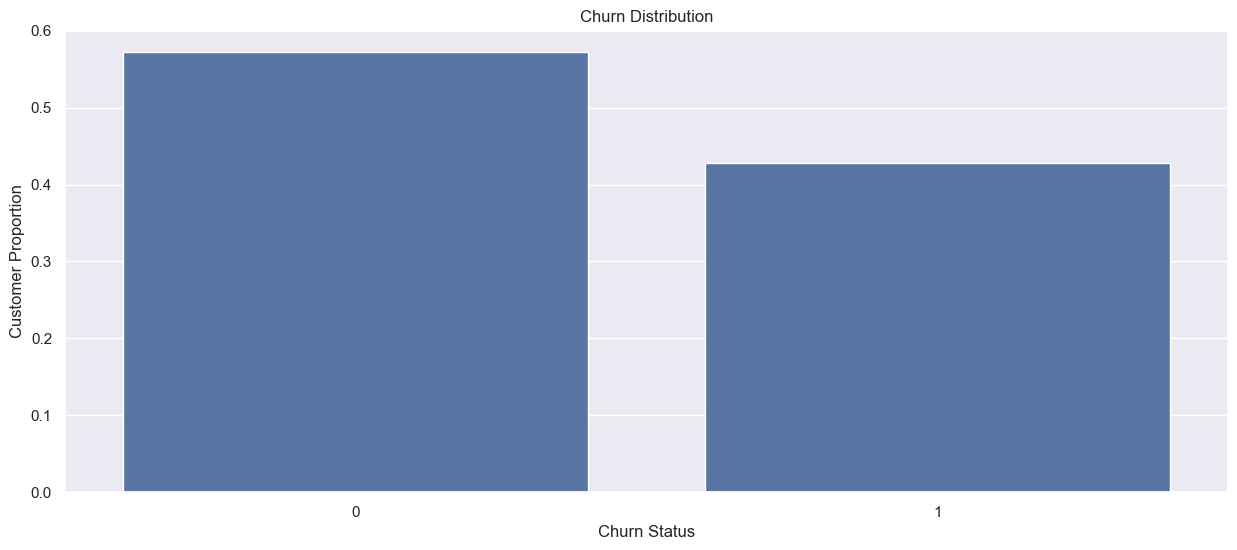

In [10]:
# Exploring the target variable
plt.figure(figsize=(15, 6))
sns.countplot(
    data=df,
    x="churned",
    stat="proportion"
).set(
    title="Churn Distribution",
    xlabel="Churn Status",
    ylabel="Customer Proportion"
);

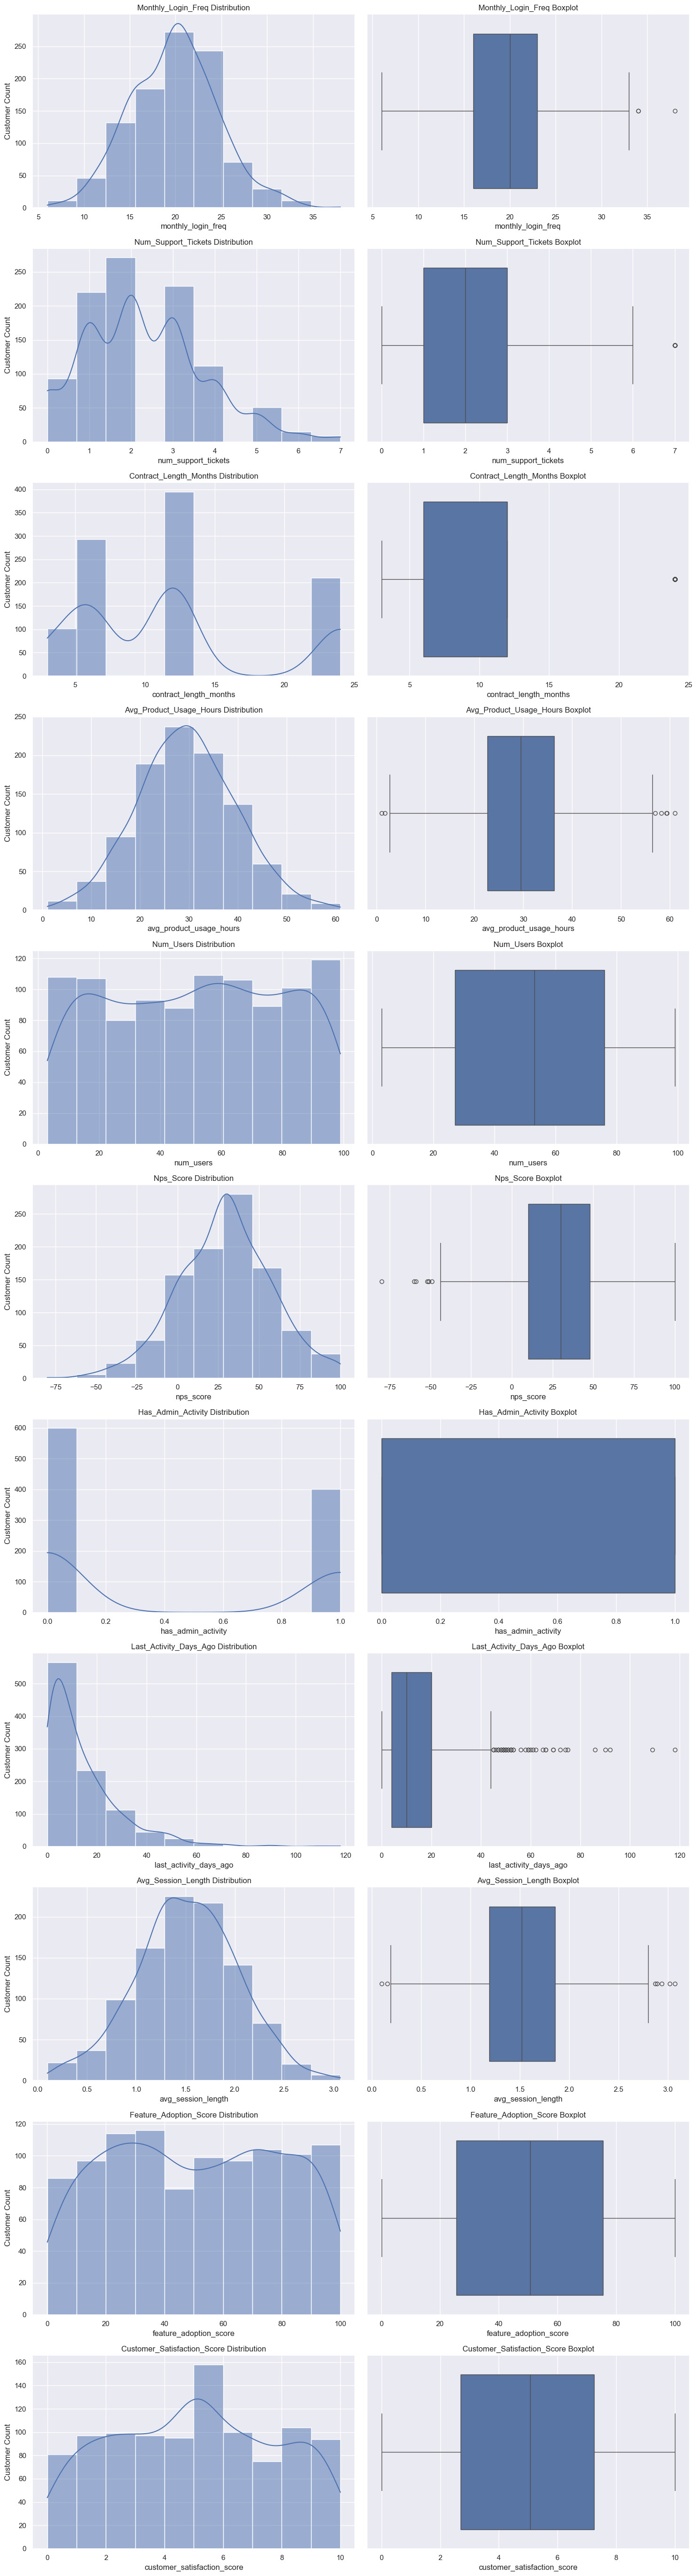

In [11]:
# Explore numeric variables
num_cols = df.select_dtypes(include="number").drop("churned", axis=1).columns
n_row = len(num_cols)
n_col = 2

fig, axs = plt.subplots(n_row, n_col, figsize=(15, 5 * n_row))

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        bins=10,
        kde=True,
        ax=axs[i, 0]
    ).set(
        xlabel=col,
        ylabel="Customer Count",
        title=f"{col.title()} Distribution"
    )

    sns.boxplot(
        data=df,
        x=col,
        ax=axs[i, 1]
    ).set(
        xlabel=col,
        title=f"{col.title()} Boxplot"
    )

plt.tight_layout()

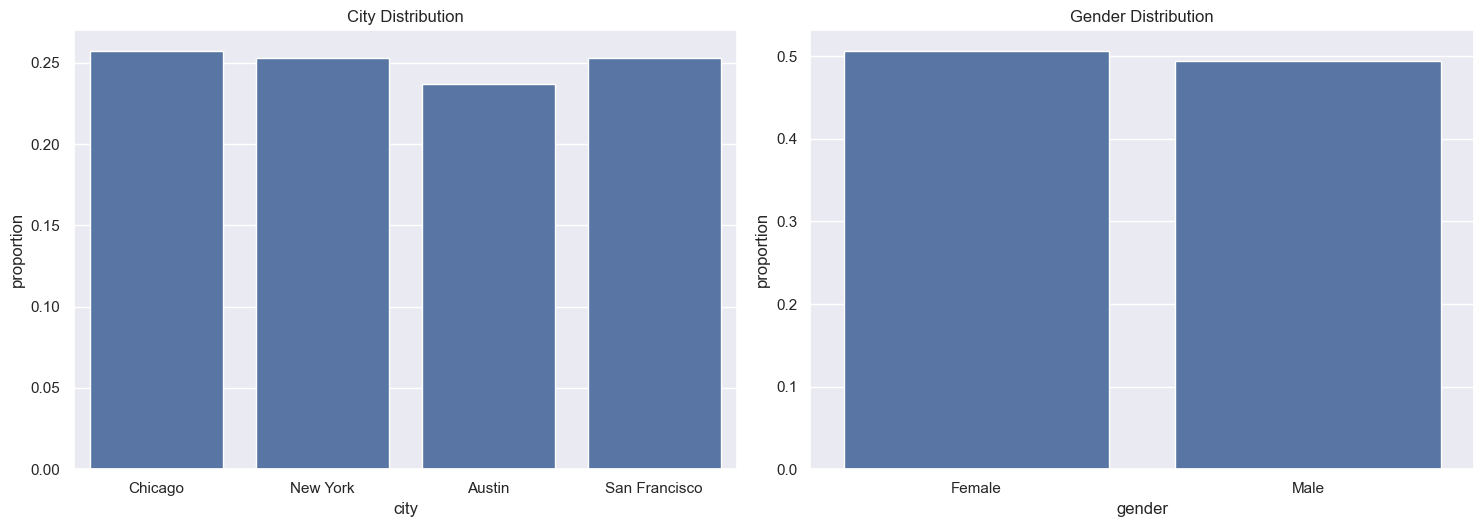

In [12]:
# Explore catgeorical variables
n_row = len(cat_col)
n_col = 2

fig, axs = plt.subplots(n_row, n_col, figsize=(15, 5 * n_row))
axs = axs.flatten()

for ax, col in zip(axs, cat_col):
    sns.countplot(
        data=df,
        x=col,
        stat="proportion",
        ax=ax
    ).set(
        title=f"{col.title()} Distribution"
    )

# Remove unused axes if any
for ax in axs[len(cat_col):]:
    ax.remove()
    
plt.tight_layout()

## Feature-Target Relationship

### Numeric

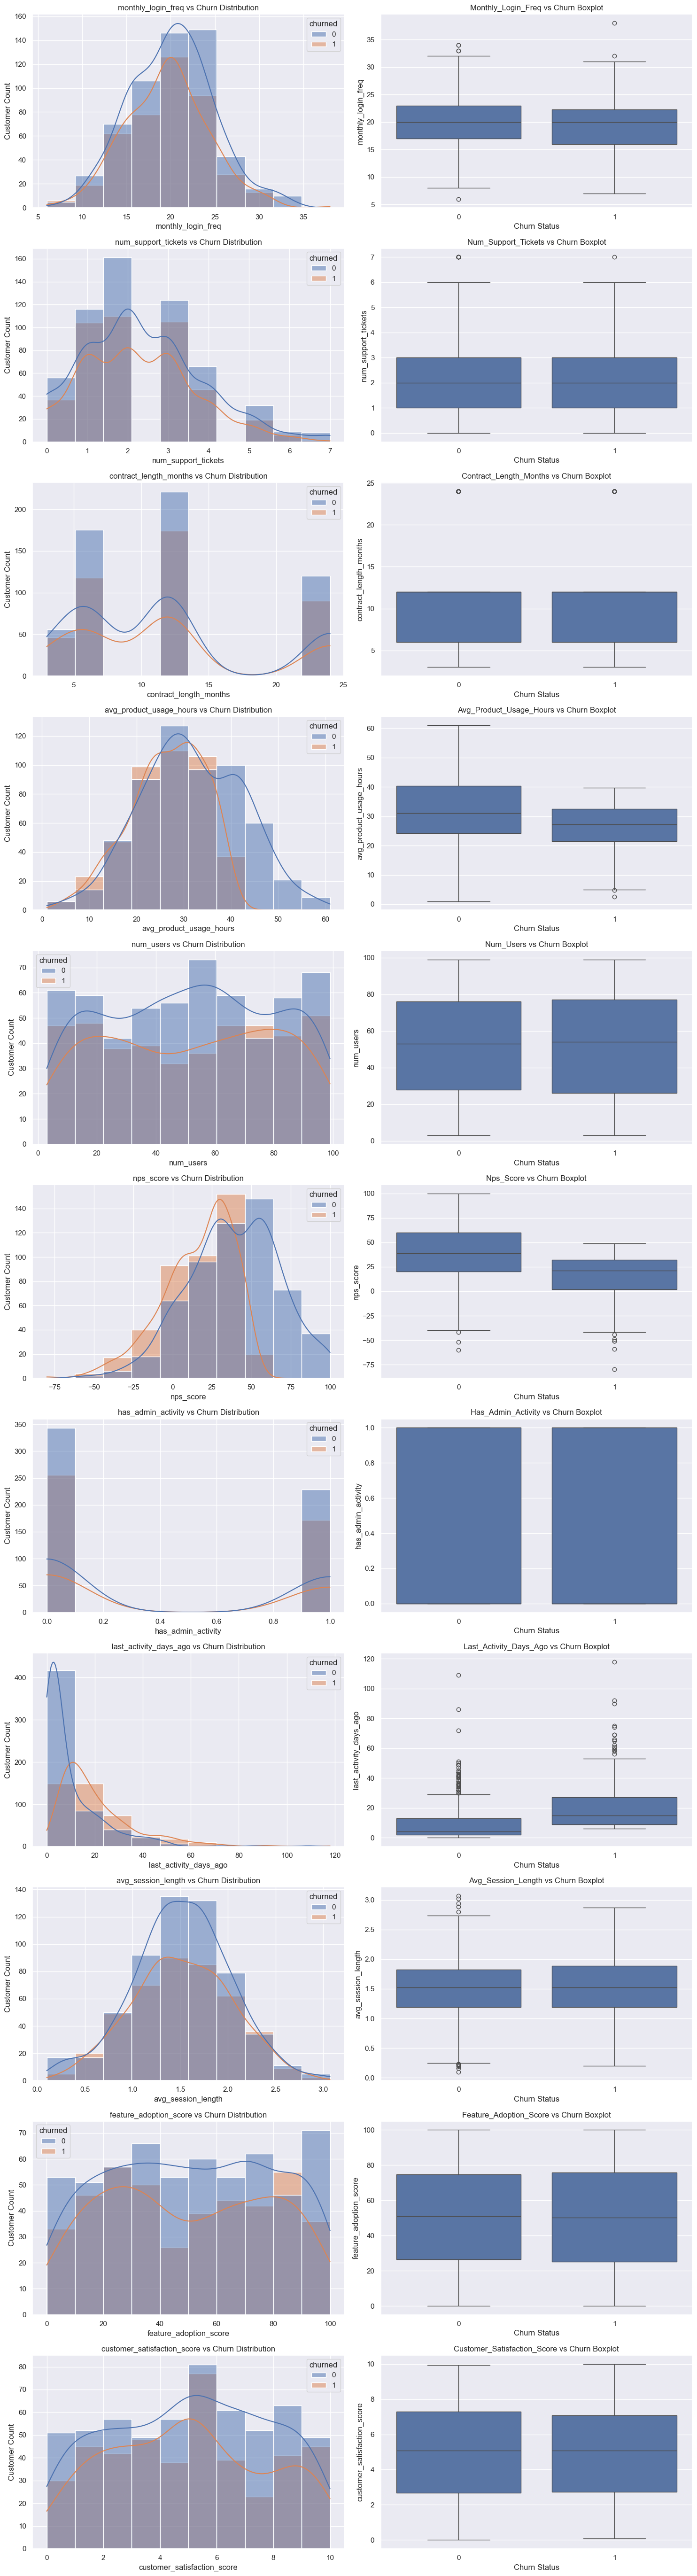

In [13]:
# Explore numeric variables
n_row = len(num_cols)
n_col = 2

fig, axs = plt.subplots(n_row, n_col, figsize=(15, 5 * n_row))

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=10,
        hue="churned",
        ax=axs[i, 0]
    ).set(
        xlabel=col,
        ylabel="Customer Count",
        title=f"{col} vs Churn Distribution"
    )

    sns.boxplot(
        data=df,
        x="churned",
        y=col,
        ax=axs[i, 1]
    ).set(
        xlabel="Churn Status",
        title=f"{col.title()} vs Churn Boxplot"
    )

plt.tight_layout()

#### Insights
* Churned users show lower and even negative NPS values, as unhappy customers are most likely to churn.
* Churned users cluster around lower usage hours, indicating low product adoption/use strongly increases churn probability.
* Churned users show lower median login frequency.
* Churned users have much higher inactivity periods. The longer users stay inactive, the higher the churn probability.

In summary, customers that have low nps score, are inactive for long period, use the product less frequently, and log in less often are most likely to churn.

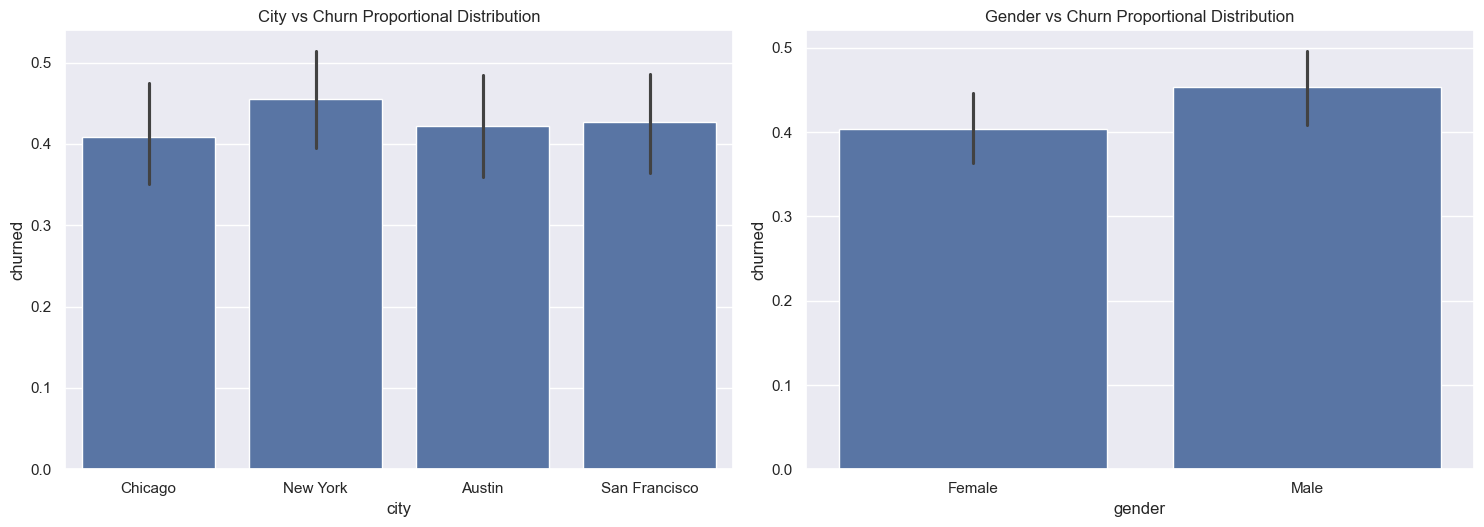

In [14]:
# Categorical variables relationship with target variable
n_row = len(cat_col)
n_col = 2

fig, axs = plt.subplots(n_row, n_col, figsize=(15, 5 * n_row))
axs = axs.flatten()

for ax, col in zip(axs, cat_col):
    sns.barplot(
        data=df,
        y="churned",
        x=col,
        ax=ax
    ).set(
        title=f"{col.title()} vs Churn Proportional Distribution"
    )

# remove unused axes
for ax in axs[len(cat_col):]:
    ax.remove()
    
plt.tight_layout()

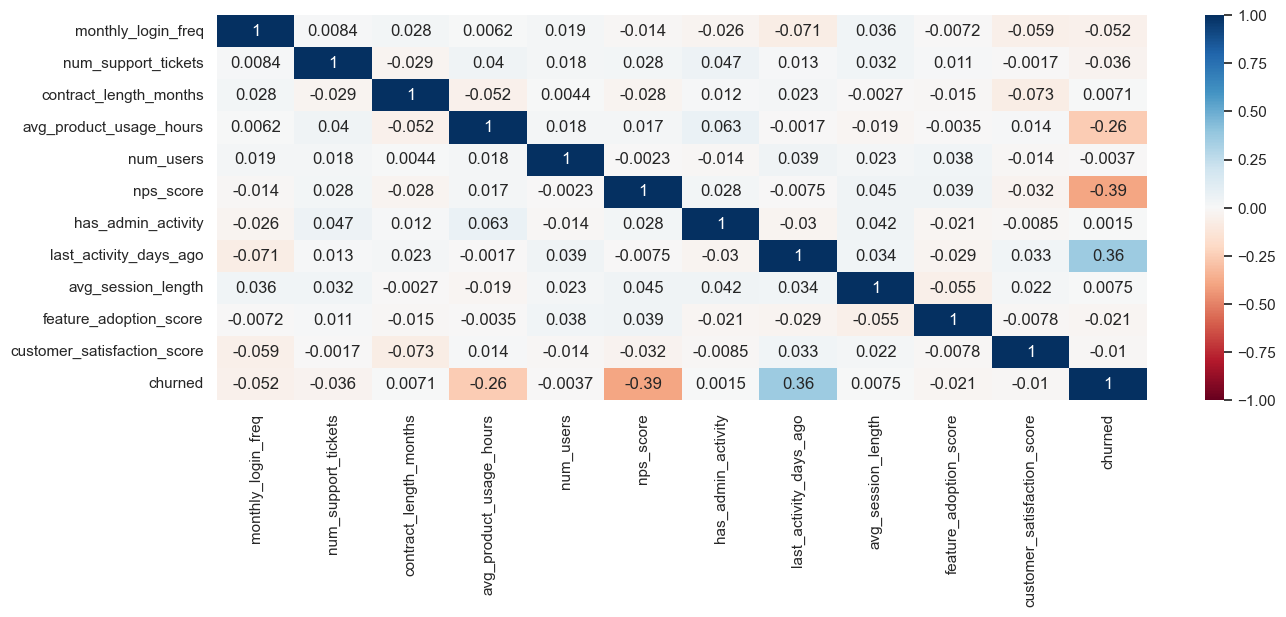

In [15]:
# check for correlation
plt.figure(figsize=(15, 5))
sns.heatmap(
    df.corr(numeric_only=True),
    vmin=-1,
    vmax=1,
    cmap="RdBu",
    annot=True);

## More Insights (Feature Interactions)

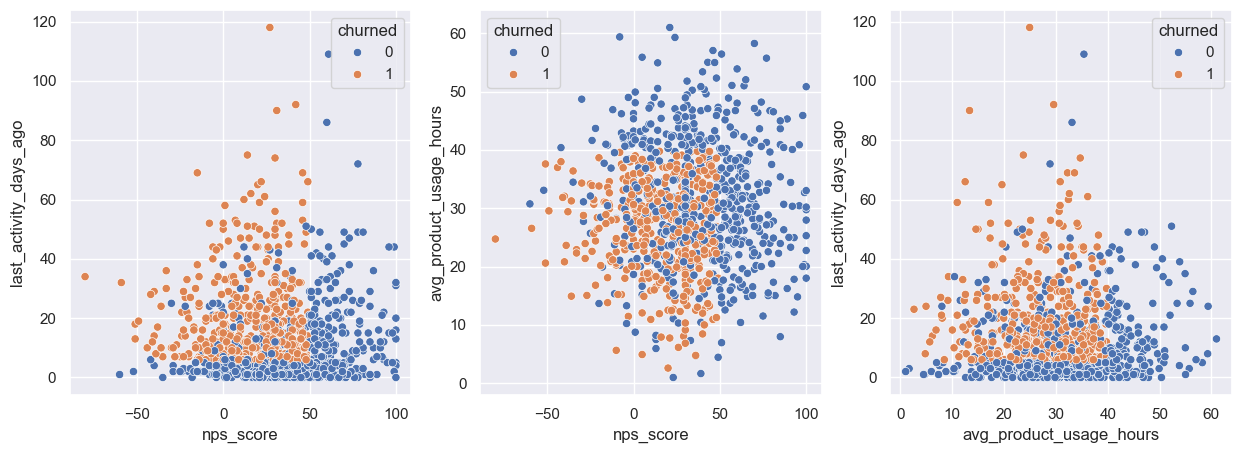

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(data=df, x="nps_score", y="last_activity_days_ago", hue="churned", ax=axs[0])

sns.scatterplot(data=df, x="nps_score", y="avg_product_usage_hours", hue="churned", ax=axs[1])

sns.scatterplot(data=df, x="avg_product_usage_hours", y="last_activity_days_ago", hue="churned", ax=axs[2]);
